In [26]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

def solve_pde_fd(f, x, t, initial_condition=None):
    """
    Solve the PDE ∂u/∂t - ∂²u/∂x² = f(x,t) with Crank-Nicolson.
    
    Args:
        f (callable or array): [num_pt_x, num_pt_t]
        t_max (float): Maximum time
        nx (int): Spatial grid points
        nt (int): Time steps
        initial_condition (array or callable): Initial condition u(x,0). If None, defaults to zero.
    
    Returns:
        tuple: (x_grid, t_grid, solution)
    """
    # Grid setup
   
    nx = len(x)
    nt = len(t)
    dx = x[1] - x[0]
    dt = t[1] - t[0]
    r = dt / (2 * dx**2)  # Crank-Nicolson parameter

    # Initialize solution
    u = np.zeros((nt, nx))

    # Set initial condition
    if initial_condition is not None:
        if callable(initial_condition):
            u[0, :] = initial_condition(x)
        else:
            u[0, :] = initial_condition  # Assume it's an array of shape (nx,)

    # Construct sparse matrix (implicit part)
    main_diag = np.ones(nx-2) * (1 + 2*r)
    off_diag = np.ones(nx-3) * (-r)
    A = diags([off_diag, main_diag, off_diag], [-1, 0, 1], format='csr')

    # Time-stepping
    for n in range(nt-1):
        t_n = t[n]
        t_n1 = t[n+1]
        
        # Evaluate f(x,t) at current and next time steps
        if callable(f):
            f_current = f(x[1:-1], t_n)
            f_next = f(x[1:-1], t_n1)
        else:  # Assume it's an array of shape (nx, nt)
            f_current = f[1:-1, n]
            f_next = f[1:-1, n+1]
        
        # Explicit RHS vector
        b = u[n, 1:-1] + r * (u[n, :-2] - 2*u[n, 1:-1] + u[n, 2:]) + dt * (f_current + f_next)/2
        
        # Solve the system
        u[n+1, 1:-1] = spsolve(A, b)
        
        # Enforce boundary conditions (Dirichlet: u=0 at boundaries)
        u[n+1, 0] = 0
        u[n+1, -1] = 0
    
    return x, t, u

def rhs_pde(x, t):
    r = 0.01
    v = 20
    result = (100 + 10. * np.sin(3 * 2 * np.pi * t[None, :])) * np.exp(-2. * (x[:, None] - v * t[None, :]) ** 2 / r**2)
    print("Size of rhs_pde:", result.shape)
    return result

In [27]:
# Example with a sinusoidal initial condition
x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)
x, t, U_fdm = solve_pde_fd(rhs_pde(x, t.reshape(-1)), x, t,
                        initial_condition=lambda x: 0.05,
                        )

Size of rhs_pde: (100, 100)


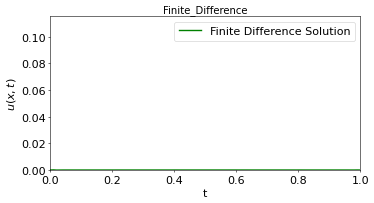

In [21]:
# Initiate the plot
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4), dpi=50)

line_analytical, = ax.plot([], [], label='Finite Difference Solution', color='green', linewidth=2)

ax.set_title('Finite_Difference', fontsize=14.5)
ax.set_xlabel('t', fontsize=16)
ax.set_ylabel(r'$u(x,t)$', fontsize=16)
ax.legend(fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
text = ax.text(0.02, 0.85, '', transform=ax.transAxes, fontsize=16)

# Set limits
ax.set_xlim(np.min(x), np.max(x))
ax.set_ylim(np.min(U_fdm), np.max(U_fdm))

# Animation update function
def update(frame):
    current_time_step = frame
    line_analytical.set_data(x.reshape(-1), U_fdm[current_time_step, :])
    return line_analytical, text

# Create animation
anim = FuncAnimation(fig, update, frames=range(np.array(t.shape[0])), blit=True)

# Save the animation
anim.save('Finite_Difference.gif', dpi=100, writer='pillow', fps=10)

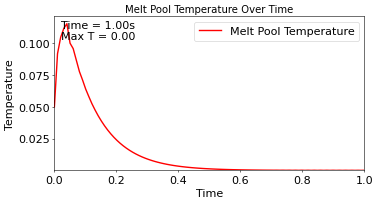

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Compute max temperature over time
max_temp_over_time = np.max(U_fdm, axis=1)  # Shape: (num_time_steps,)
time = t  # assuming t is 1D array of time values, shape: (num_time_steps,)

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(8, 4), dpi=50)
line, = ax.plot([], [], color='red', linewidth=2, label='Melt Pool Temperature')

ax.set_title('Melt Pool Temperature Over Time', fontsize=14.5)
ax.set_xlabel('Time', fontsize=16)
ax.set_ylabel('Temperature', fontsize=16)
ax.legend(fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)

ax.set_xlim(np.min(time), np.max(time))
ax.set_ylim(np.min(max_temp_over_time), np.max(max_temp_over_time) * 1.05)

# Create a text label for the current max
text = ax.text(0.02, 0.85, '', transform=ax.transAxes, fontsize=16)

# Animation update function
def update(frame):
    current_time = time[:frame+1]
    current_max = max_temp_over_time[:frame+1]
    line.set_data(current_time, current_max)
    text.set_text(f'Time = {time[frame]:.2f}s\nMax T = {max_temp_over_time[frame]:.2f}')
    return line, text

# Create animation
anim = FuncAnimation(fig, update, frames=len(time), blit=True)

# Save the animation
anim.save('Melt_Pool_Over_Time.gif', dpi=100, writer='pillow', fps=10)

